In [1]:
# %% Cell 1 — Load libraries and cleaned data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from scipy import stats

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_parquet('../data/processed/cleaned.parquet')
df['date'] = pd.to_datetime(df['date'])

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Columns: {df.columns.tolist()}")

Loaded 5477 rows
Date range: 2011-01-01 to 2025-12-31
Columns: ['date', 'rides', 'temp_mean', 'temp_max', 'temp_min', 'precipitation', 'windspeed', 'weather_code', 'weather_desc', 'is_holiday', 'year', 'month', 'day_of_week', 'is_weekend', 'season', 'season_name', 'is_rainy', 'day_type', 'rides_vs_yearly_avg']


In [2]:
# %% Cell 2 — Define features and target
# These are the variables we use to predict ride counts
# We only include variables that represent CONDITIONS on that day
# not things derived from rides itself

feature_cols = [
    'temp_mean',      # average temperature that day
    'temp_max',       # maximum temperature
    'temp_min',       # minimum temperature
    'precipitation',  # rainfall in mm
    'windspeed',      # wind speed
    'is_holiday',     # 1 if public holiday
    'is_weekend',     # 1 if Saturday or Sunday
    'is_rainy',       # 1 if precipitation > 1mm
    'month',          # month of year (1-12)
    'day_of_week',    # day of week (0=Mon, 6=Sun)
    'season',         # season (1-4)
]

target = 'rides'

X = df[feature_cols]
y = df[target]

print("Features:", feature_cols)
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget variable stats:")
print(f"  Mean:   {y.mean():,.0f}")
print(f"  Min:    {y.min():,.0f}")
print(f"  Max:    {y.max():,.0f}")
print(f"  Std:    {y.std():,.0f}")

Features: ['temp_mean', 'temp_max', 'temp_min', 'precipitation', 'windspeed', 'is_holiday', 'is_weekend', 'is_rainy', 'month', 'day_of_week', 'season']

X shape: (5477, 11)
y shape: (5477,)

Target variable stats:
  Mean:   26,583
  Min:    188
  Max:    73,094
  Std:    9,176


In [3]:
# %% Cell 3 — Train/test split
# We use a random split here because we are doing regression
# not forecasting — we want to explain what causes rides
# not predict future values
# random_state=42 makes the split reproducible for everyone

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test samples:     {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

Training samples: 4381 (80%)
Test samples:     1096 (20%)


In [4]:
# %% Cell 4 — Model 1: Linear Regression (baseline)
# Always start with a simple model as a baseline
# Linear regression fits a straight line through the data
# The coefficients directly tell you the effect of each variable
# e.g. if temp_mean coefficient = 1007, each +1 degree = +1007 rides

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2  = r2_score(y_test, lr_preds)

print("=== LINEAR REGRESSION ===")
print(f"MAE: {lr_mae:,.0f} rides")
print(f"R²:  {lr_r2:.3f}")
print()

# Print coefficients — this is the most readable output
# Each number = how many more/fewer rides for +1 unit of that variable
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=False)

print("Coefficients (effect on rides per unit increase):")
print(coef_df.to_string(index=False))

=== LINEAR REGRESSION ===
MAE: 4,556 rides
R²:  0.555

Coefficients (effect on rides per unit increase):
      feature  coefficient
     temp_max   724.099200
    temp_mean   571.767111
        month    48.844377
  day_of_week   -87.910515
    windspeed  -100.202639
precipitation  -462.256984
     temp_min  -471.452260
       season  -603.829883
     is_rainy -1751.601455
   is_weekend -4196.735843
   is_holiday -6357.150363


In [5]:
# %% Cell 5 — Model 2: XGBoost Regressor
# XGBoost builds many decision trees and combines them
# More powerful than linear regression because it can capture
# non-linear relationships
# e.g. temperature might have a bigger effect above 15°C than below it
# Linear regression can't capture that — XGBoost can

xgb = XGBRegressor(
    n_estimators=300,    # build 300 trees
    learning_rate=0.05,  # each tree contributes a small amount
    max_depth=4,         # not too deep — avoids overfitting
    random_state=42,
    verbosity=0          # suppress output during training
)

xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2  = r2_score(y_test, xgb_preds)

print("=== XGBOOST REGRESSOR ===")
print(f"MAE: {xgb_mae:,.0f} rides")
print(f"R²:  {xgb_r2:.3f}")

=== XGBOOST REGRESSOR ===
MAE: 4,379 rides
R²:  0.595


In [7]:
# %% Cell 6 — Compare both models
print("=== MODEL COMPARISON ===")
print(f"{'Model':<25} {'MAE':>10} {'R²':>8}")
print("-" * 45)
print(f"{'Linear Regression':<25} {lr_mae:>10,.0f} {lr_r2:>8.3f}")
print(f"{'XGBoost':<25} {xgb_mae:>10,.0f} {xgb_r2:>8.3f}")
print()
print("MAE = Mean Absolute Error")
print("     = on average, prediction is off by this many rides per day")
print("     Lower is better")


=== MODEL COMPARISON ===
Model                            MAE       R²
---------------------------------------------
Linear Regression              4,556    0.555
XGBoost                        4,379    0.595

MAE = Mean Absolute Error
     = on average, prediction is off by this many rides per day
     Lower is better


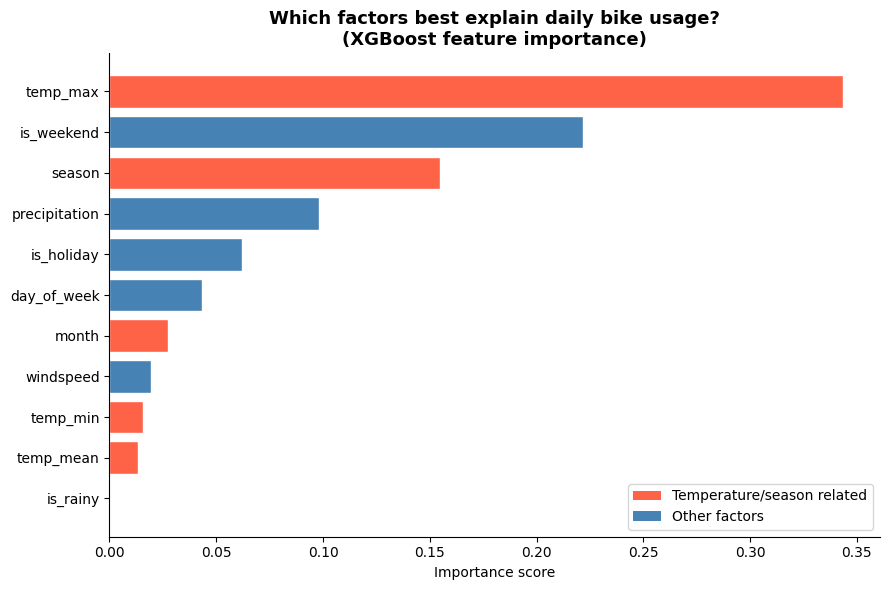

Feature importance ranking:
temp_max         0.3437
is_weekend       0.2219
season           0.1550
precipitation    0.0979
is_holiday       0.0623
day_of_week      0.0435
month            0.0276
windspeed        0.0193
temp_min         0.0156
temp_mean        0.0134
is_rainy         0.0000
dtype: float32


In [8]:
# %% Cell 7 — XGBoost Feature Importance plot
# This is your most important output for the research question
# It shows which variables the model relied on most
# to explain ride counts

importance = pd.Series(
    xgb.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['tomato' if 'temp' in col or col == 'month' or col == 'season'
          else 'steelblue' for col in importance.index]

bars = ax.barh(importance.index, importance.values,
               color=colors, edgecolor='white')

ax.set_title('Which factors best explain daily bike usage?\n(XGBoost feature importance)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance score')

# Add a legend explaining colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato', label='Temperature/season related'),
    Patch(facecolor='steelblue', label='Other factors')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../notebooks/plot_08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance ranking:")
print(importance.sort_values(ascending=False).round(4))

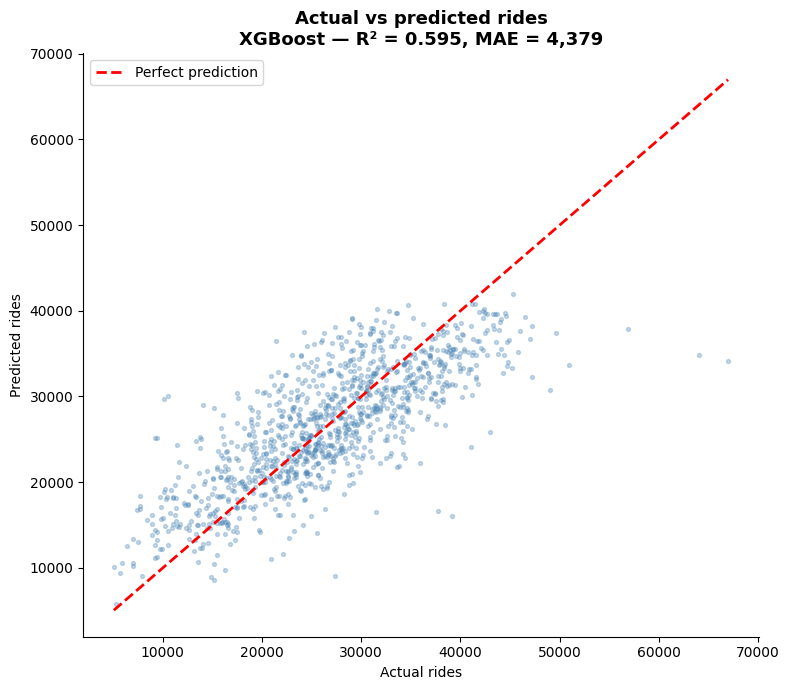

In [9]:
# %% Cell 8 — Actual vs Predicted plot
# Shows how well the model predicts ride counts
# Each dot is one day from the test set
# Perfect predictions would all lie on the diagonal line

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_test, xgb_preds, alpha=0.3, s=8, color='steelblue')

# Perfect prediction line
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual rides')
ax.set_ylabel('Predicted rides')
ax.set_title(f'Actual vs predicted rides\nXGBoost — R² = {xgb_r2:.3f}, MAE = {xgb_mae:,.0f}',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/plot_09_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# %% Cell 9 — Final complete summary
print("=" * 55)
print("COMPLETE PROJECT FINDINGS SUMMARY")
print("=" * 55)

# Temperature from linear regression
temp_coef = coef_df[coef_df['feature'] == 'temp_mean']['coefficient'].values[0]
corr, pval = stats.pearsonr(df['temp_mean'], df['rides'])

print(f"\nTEMPERATURE EFFECT:")
print(f"  Each +1°C = +{temp_coef:.0f} more rides per day (linear regression)")
print(f"  Correlation with rides: r = {corr:.3f}")
print(f"  Temperature explains {corr**2*100:.1f}% of ride variation")
print(f"  P-value: {pval:.6f} (statistically significant)")

# Holiday effect
hol_coef = coef_df[coef_df['feature'] == 'is_holiday']['coefficient'].values[0]
weekday_avg = df[df['day_type'] == 'Weekday']['rides'].mean()
holiday_avg = df[df['day_type'] == 'Holiday']['rides'].mean()
pct = (holiday_avg - weekday_avg) / weekday_avg * 100
t_stat, p_hol = stats.ttest_ind(
    df[df['day_type'] == 'Holiday']['rides'],
    df[df['day_type'] == 'Weekday']['rides']
)

print(f"\nHOLIDAY EFFECT:")
print(f"  Weekday average: {weekday_avg:,.0f} rides")
print(f"  Holiday average: {holiday_avg:,.0f} rides")
print(f"  Holidays have {pct:.1f}% rides vs normal weekdays")
print(f"  Linear regression: being a holiday = {hol_coef:+.0f} rides/day")
print(f"  T-test p-value: {p_hol:.6f} (statistically significant)")

# Rain
rain_coef = coef_df[coef_df['feature'] == 'precipitation']['coefficient'].values[0]
dry = df[df['is_rainy']==0]['rides'].mean()
rainy = df[df['is_rainy']==1]['rides'].mean()

print(f"\nRAIN EFFECT:")
print(f"  Each +1mm precipitation = {rain_coef:.0f} rides/day")
print(f"  Rainy days have {(rainy-dry)/dry*100:.1f}% rides vs dry days")

# Model performance
print(f"\nMODEL PERFORMANCE:")
print(f"  Linear Regression — MAE: {lr_mae:,.0f} rides, R²: {lr_r2:.3f}")
print(f"  XGBoost           — MAE: {xgb_mae:,.0f} rides, R²: {xgb_r2:.3f}")

# Top features
print(f"\nTOP 3 MOST IMPORTANT FEATURES (XGBoost):")
top3 = importance.sort_values(ascending=False).head(3)
for i, (feat, imp) in enumerate(top3.items(), 1):
    print(f"  {i}. {feat} (importance: {imp:.4f})")

COMPLETE PROJECT FINDINGS SUMMARY

TEMPERATURE EFFECT:
  Each +1°C = +572 more rides per day (linear regression)
  Correlation with rides: r = 0.604
  Temperature explains 36.5% of ride variation
  P-value: 0.000000 (statistically significant)

HOLIDAY EFFECT:
  Weekday average: 28,077 rides
  Holiday average: 20,545 rides
  Holidays have -26.8% rides vs normal weekdays
  Linear regression: being a holiday = -6357 rides/day
  T-test p-value: 0.000000 (statistically significant)

RAIN EFFECT:
  Each +1mm precipitation = -462 rides/day
  Rainy days have -20.0% rides vs dry days

MODEL PERFORMANCE:
  Linear Regression — MAE: 4,556 rides, R²: 0.555
  XGBoost           — MAE: 4,379 rides, R²: 0.595

TOP 3 MOST IMPORTANT FEATURES (XGBoost):
  1. temp_max (importance: 0.3437)
  2. is_weekend (importance: 0.2219)
  3. season (importance: 0.1550)
